# Vegetation dynamics and Climate Drivers
- Created on 3/17/2026

In [1]:
from google.auth import compute_engine
import ee
print(ee.__version__)
import os

0.1.370


In [4]:
# Trigger the authentication flow.
# ee.Authenticate()

# ======================================================
# 0. Initialization
# ======================================================
import ee
ee.Initialize(project='rse-global-wetlands')

In [15]:
# ======================================================
# 1. Assets (AOIs & stations)
# ======================================================
Tata_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Tata_Morocco_Working_Area')
Eastern_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area')
Bouarfa = ee.FeatureCollection('projects/rse-global-wetlands/assets/Bouarfa_study_area')
AI_Baten = ee.FeatureCollection('projects/rse-global-wetlands/assets/Al_Baten_study_area')
stations = ee.FeatureCollection('projects/rse-global-wetlands/assets/Trophic_survey_data_114_station_habitat_26') #UPDATED ON 3/17/2026
OUT_FOLDER = 'GEE_Clim_exports'

In [16]:
# print(Bouarfa.first().getInfo()) #name_en
# print(AI_Baten.first().getInfo())
print(stations.first().getInfo()) # 'Habitat_f2' == 'Habitat_2_'

{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [-4.0352902529221675, 33.20026810713866]}, 'id': '00000000000000000000', 'properties': {'Approach': 'Habitat', 'Code': 'ALF', 'Habitat': 'Macrochloa steppe', 'Habitat_2_': 'Alfah-grass steppe', 'Habitat_Fr': 'Alfatière', 'Habitat_en': 'Macrochloa steppe', 'Habitat_f1': 'Alfah-grass steppe', 'Habitat_f2': 'Alfah-grass steppe', 'Lat': 33.20027, 'Lon': -4.03529, 'Station': 'ALBALF1', 'Sub_area': 'AI Baten', 'Work_area': 'EM'}}


In [80]:
# ======================================================
# 1. Assets (AOIs & stations)
# ======================================================
Tata_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Tata_Morocco_Working_Area')
Eastern_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area')
Bouarfa = ee.FeatureCollection('projects/rse-global-wetlands/assets/Bouarfa_study_area')
AI_Baten = ee.FeatureCollection('projects/rse-global-wetlands/assets/Al_Baten_study_area')
# stations = ee.FeatureCollection('projects/rse-global-wetlands/assets/Trophic_survey_data_114_station_habitat')
OUT_FOLDER = 'GEE_Clim_exports'
OUT_FOLDER2 = 'GEE_Clim_Station_exports'
ID = 'name_en'

# ======================================================
# 2. Time range
# ======================================================
START_YEAR = 2007
END_YEAR = 2008

# ======================================================
# 3. Load & preprocess ERA5 daily dataset
# ======================================================
# ref to the dataset:https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_DAILY_AGGR#bands
def process_era5_daily(img):
    # Temperature (K -> °C)
    temp = img.select("temperature_2m").subtract(273.15).rename("temp2m_C")
    temp_max = img.select("temperature_2m_max").subtract(273.15).rename("temp2m_C_max")
    temp_min = img.select("temperature_2m_min").subtract(273.15).rename("temp2m_C_min")
    
    # Precipitation (m -> mm)
    precip = img.select("total_precipitation_sum").multiply(1000).rename("precip_mm")
    
    return ee.Image.cat([temp, temp_max, temp_min, precip]) \
        .copyProperties(img, ["system:time_start"])

# Load ERA5 Daily
era5_daily = (
    ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
    .filter(ee.Filter.calendarRange(START_YEAR, END_YEAR, "year"))
    .map(process_era5_daily)
    .select(["temp2m_C", "temp2m_C_max", "temp2m_C_min", "precip_mm"])
)

# ======================================================
# 4. Export function for stations (loop over each station)
# ======================================================
def export_station_daily(fc, era5_ic, folder, id_field="Station", habitat_field="Habitat_2_"):

    # Keep only ID and habitat fields
    fc_clean = fc.select([id_field, habitat_field])

    def reduce_img(img):
        reduced = img.reduceRegions(
            collection=fc_clean,
            reducer=ee.Reducer.mean(),
            scale=9000  # match ERA5 resolution
        )
        
        # Build clean feature (no geometry)
        return reduced.map(lambda f: ee.Feature(None, {
            "station_id": f.get(id_field),
            "habitat": f.get(habitat_field),
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            # "time_start": img.get("system:time_start"),
            "temp2m_C": f.get("temp2m_C"),
            "temp2m_C_max": f.get("temp2m_C_max"),
            "temp2m_C_min": f.get("temp2m_C_min"),
            "precip_mm": f.get("precip_mm")
        }))

    # Loop yearly
    for year in range(START_YEAR, END_YEAR + 1):
        era5_year = era5_ic.filter(ee.Filter.calendarRange(year, year, "year"))
        
        table = era5_year.map(reduce_img).flatten()
        
        task = ee.batch.Export.table.toDrive(
            collection=table,
            description=f"ERA5_Stations_Daily_{year}",
            folder=folder,
            fileNamePrefix=f"ERA5_Stations_Daily_{year}",
            fileFormat="CSV"
        )
        task.start()
        
        print(f"Export started for year: {year}")

# ======================================================
# 5. Export function for areas (reduceRegions)
# ======================================================
def export_area_daily(fc, era5_ic, folder, id_field):

    # Keep only the ID field (avoid redundant attributes)
    fc_clean = fc.select([id_field])

    def reduce_img(img):
        reduced = img.reduceRegions(
            collection=fc_clean,
            reducer=ee.Reducer.mean(),
            scale=9000  # ERA5 resolution
        )
        
        # Build clean feature (no geometry, only needed fields)
        return reduced.map(lambda f: ee.Feature(None, {
            "area_id": f.get(id_field),
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            "time_start": img.get("system:time_start"),
            "temp2m_C": f.get("temp2m_C"),
            "temp2m_C_max": f.get("temp2m_C_max"),
            "temp2m_C_min": f.get("temp2m_C_min"),
            "precip_mm": f.get("precip_mm")
        }))

    # Loop yearly
    for year in range(START_YEAR, END_YEAR + 1):
        era5_year = era5_ic.filter(ee.Filter.calendarRange(year, year, "year"))
        
        table = era5_year.map(reduce_img).flatten()
        
        task = ee.batch.Export.table.toDrive(
            collection=table,
            description=f"ERA5_Areas_Daily_{year}",
            folder=folder,
            fileNamePrefix=f"ERA5_Areas_Daily_{year}",
            fileFormat="CSV"
        )
        task.start()
        
        print(f"Export started for year: {year}")    
# ======================================================
# 6. Run exports
# ======================================================
# export_station_daily(stations,era5_daily,OUT_FOLDER2,id_field="Station",habitat_field="Habitat_2_")
export_area_daily(AI_Baten.merge(Bouarfa), era5_daily, OUT_FOLDER, id_field = 'name_en')

print("All export tasks started. Check GEE Tasks tab or your Google Drive folder.")


Export started for year: 2007
Export started for year: 2008
All export tasks started. Check GEE Tasks tab or your Google Drive folder.


In [ ]:
# the grid was updated: 56 grid cells, based on the overlap of 114 vegetation field plots

ERA5_GRID = ee.FeatureCollection('projects/rse-global-wetlands/assets/ERA5_Grid_Veg_seleted');
print(ERA5_GRID.first().getInfo())

def export_grid_daily(fc, era5_ic, folder, id_field):

    fc_clean = fc.select([id_field])

    def reduce_img(img):
        reduced = img.reduceRegions(
            collection=fc_clean,
            reducer=ee.Reducer.mean(),
            scale=9000
        )

        return reduced.map(lambda f: ee.Feature(None, {
            "grid_id": f.get(id_field),
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            "temp2m_C": f.get("temp2m_C"),
            "temp2m_C_max": f.get("temp2m_C_max"),
            "temp2m_C_min": f.get("temp2m_C_min"),
            "precip_mm": f.get("precip_mm")
        }))

    for year in range(START_YEAR, END_YEAR + 1):
        era5_year = era5_ic.filter(ee.Filter.calendarRange(year, year, "year"))

        table = era5_year.map(reduce_img).flatten()

        task = ee.batch.Export.table.toDrive(
            collection=table,
            description=f"ERA5_Grid_Daily_{year}",
            folder=folder,
            fileNamePrefix=f"ERA5_Grid_Daily_{year}",
            fileFormat="CSV"
        )

        task.start()
        print(f"Grid export started for year: {year}")

export_grid_daily(
    ERA5_GRID,
    era5_daily,
    OUT_FOLDER,
    id_field="grid_id"   # change if your field name differs
)




In [46]:
# Combint the yearly seperated CSV files into one

import pandas as pd
import glob
import os

# Folder containing exported CSVs
folder = "C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Climate data/GEE_Clim_exports"

# Get all yearly files
files = sorted(glob.glob(os.path.join(folder, "ERA5_Areas_Daily_*.csv")))

# Read and concatenate
df = pd.concat(
    (pd.read_csv(f) for f in files),
    ignore_index=True
)

print(df.shape)
print(df.columns.tolist())

# Only keep the columns are needed
cols_keep = [
    "area_id",
    "date",
    "precip_mm",
    "temp2m_C",
    "temp2m_C_max",
    "temp2m_C_min"
]

df = df[cols_keep]

print(df.shape)

# Convert time
df["date"] = pd.to_datetime(df["date"])
# Sort (critical for time series)
df = df.sort_values(["area_id", "date"])
# Remove potential duplicates
df = df.drop_duplicates(subset=["area_id", "date"])

# Check data integrity
print(df.isna().sum())
print(df.groupby("area_id").size())

df.to_csv(os.path.join(folder, "ERA5_daily_08-25_AI Baten_Bouarfa_merged.csv"), index=False)

In [48]:
# For stations
sta_files = sorted(glob.glob(os.path.join(folder, "ERA5_Stations_Daily_*.csv")))

# Read and concatenate
df1 = pd.concat(
    (pd.read_csv(f) for f in sta_files),
    ignore_index=True
)

print(df1.shape)

print(df1.columns.tolist())

# Only keep the columns are needed
cols_keep1 = [
    "station_id",
    "habitat",
    "date",
    "precip_mm",
    "temp2m_C",
    "temp2m_C_max",
    "temp2m_C_min"
]

df1 = df1[cols_keep1]

print(df1.shape)

# Convert time
df1["date"] = pd.to_datetime(df1["date"])
# Sort (critical for time series)
df1 = df1.sort_values(["station_id", "date"])
# Remove potential duplicates
df1 = df1.drop_duplicates(subset=["station_id", "date"])

# Check data integrity
print(df1.isna().sum())
print(df1.groupby("station_id").size())

df1.to_csv(os.path.join(folder, "ERA5_daily_10-25_stations_merged.csv"), index=False)

(666216, 9)
['system:index', 'date', 'habitat', 'precip_mm', 'station_id', 'temp2m_C', 'temp2m_C_max', 'temp2m_C_min', '.geo']
(666216, 7)
station_id      0
habitat         0
date            0
precip_mm       0
temp2m_C        0
temp2m_C_max    0
temp2m_C_min    0
dtype: int64
station_id
ALBALF1    5844
ALBALF2    5844
ALBALF3    5844
ALBLDD1    5844
ALBLDD3    5844
           ... 
WC43NE1    5844
WC43NE2    5844
WC43NE3    5844
WC43NE4    5844
WC43NE5    5844
Length: 114, dtype: int64


## Additional climatology baseline
- The monthly ERA5 data will be used as a baseline to characterize precipitation amounts in the two pilot areas, Bouarfa and Al Baten.
- ERA5-Land Monthly Aggregated - ECMWF Climate Reanalysis: https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_MONTHLY_AGGR
- Recent 15 years, from 2010-2025

In [82]:
# ======================================================
# 1. Assets (AOIs & stations)
# ======================================================
Tata_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Tata_Morocco_Working_Area')
Eastern_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area')
Bouarfa = ee.FeatureCollection('projects/rse-global-wetlands/assets/Bouarfa_study_area')
AI_Baten = ee.FeatureCollection('projects/rse-global-wetlands/assets/Al_Baten_study_area')
# stations = ee.FeatureCollection('projects/rse-global-wetlands/assets/Trophic_survey_data_114_station_habitat')
OUT_FOLDER = 'GEE_Monthly_Clim_exports'
OUT_FOLDER2 = 'GEE_Clim_Station_exports'
ID = 'name_en'

# ======================================================
# 2. Time range
# ======================================================
START_YEAR = 2010
END_YEAR = 2025

# ======================================================
# 3. Load & preprocess ERA5 daily dataset
# ======================================================
# ref to the dataset:https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_DAILY_AGGR#bands
def process_era5_monthly(img):
    # Temperature (K -> °C)
    temp = img.select("temperature_2m").subtract(273.15).rename("temp2m_C")
    temp_max = img.select("temperature_2m_max").subtract(273.15).rename("temp2m_C_max")
    temp_min = img.select("temperature_2m_min").subtract(273.15).rename("temp2m_C_min")
    
    # Precipitation (m -> mm)
    precip = img.select("total_precipitation_sum").multiply(1000).rename("precip_mm")
    
    return ee.Image.cat([temp, temp_max, temp_min, precip]) \
        .copyProperties(img, ["system:time_start"])

# Load ERA5 Daily
era5_monthly = (
    ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
    .filter(ee.Filter.calendarRange(START_YEAR, END_YEAR, "year"))
    .map(process_era5_monthly)
    .select(["temp2m_C", "temp2m_C_max", "temp2m_C_min", "precip_mm"])
)

# ======================================================
# 4. Export function for stations (loop over each station)
# ======================================================
def export_station_monthly(fc, era5_ic, folder, id_field="Station", habitat_field="Habitat_2_"):

    # Keep only ID and habitat fields
    fc_clean = fc.select([id_field, habitat_field])

    def reduce_img(img):
        reduced = img.reduceRegions(
            collection=fc_clean,
            reducer=ee.Reducer.mean(),
            scale=9000  # match ERA5 resolution
        )
        
        # Build clean feature (no geometry)
        return reduced.map(lambda f: ee.Feature(None, {
            "station_id": f.get(id_field),
            "habitat": f.get(habitat_field),
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            # "time_start": img.get("system:time_start"),
            "temp2m_C": f.get("temp2m_C"),
            "temp2m_C_max": f.get("temp2m_C_max"),
            "temp2m_C_min": f.get("temp2m_C_min"),
            "precip_mm": f.get("precip_mm")
        }))

    # Loop yearly
    for year in range(START_YEAR, END_YEAR + 1):
        era5_year = era5_ic.filter(ee.Filter.calendarRange(year, year, "year"))
        
        table = era5_year.map(reduce_img).flatten()
        
        task = ee.batch.Export.table.toDrive(
            collection=table,
            description=f"ERA5_Stations_Daily_{year}",
            folder=folder,
            fileNamePrefix=f"ERA5_Stations_Daily_{year}",
            fileFormat="CSV"
        )
        task.start()
        
        print(f"Export started for year: {year}")

# ======================================================
# 5. Export function for areas (reduceRegions)
# ======================================================
def export_area_monthly(fc, era5_ic, folder, id_field):

    # Keep only the ID field (avoid redundant attributes)
    fc_clean = fc.select([id_field])

    def reduce_img(img):
        reduced = img.reduceRegions(
            collection=fc_clean,
            reducer=ee.Reducer.mean(),
            scale=9000  # ERA5 resolution
        )
        
        # Build clean feature (no geometry, only needed fields)
        return reduced.map(lambda f: ee.Feature(None, {
            "area_id": f.get(id_field),
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            # "time_start": img.get("system:time_start"),
            "temp2m_C": f.get("temp2m_C"),
            "temp2m_C_max": f.get("temp2m_C_max"),
            "temp2m_C_min": f.get("temp2m_C_min"),
            "precip_mm": f.get("precip_mm")
        }))

    # Loop yearly
    for year in range(START_YEAR, END_YEAR + 1):
        era5_year = era5_ic.filter(ee.Filter.calendarRange(year, year, "year"))
        
        table = era5_year.map(reduce_img).flatten()
        
        task = ee.batch.Export.table.toDrive(
            collection=table,
            description=f"ERA5_Areas_Monthly_{year}",
            folder=folder,
            fileNamePrefix=f"ERA5_Areas_Monthly_{year}",
            fileFormat="CSV"
        )
        task.start()
        
        print(f"Export started for year: {year}")    
# ======================================================
# 6. Run exports
# ======================================================
# export_station_monthly(stations,era5_daily,OUT_FOLDER2,id_field="Station",habitat_field="Habitat_2_")
export_area_monthly(AI_Baten.merge(Bouarfa), era5_monthly, OUT_FOLDER, id_field = 'name_en')

print("All export tasks started. Check GEE Tasks tab or your Google Drive folder.")


Export started for year: 2012
Export started for year: 2013
Export started for year: 2014
Export started for year: 2015
Export started for year: 2016
Export started for year: 2017
Export started for year: 2018
Export started for year: 2019
Export started for year: 2020
Export started for year: 2021
Export started for year: 2022
Export started for year: 2023
Export started for year: 2024
Export started for year: 2025
All export tasks started. Check GEE Tasks tab or your Google Drive folder.


In [83]:
# Combint the yearly seperated CSV files into one

import pandas as pd
import glob
import os

# Folder containing exported CSVs
folder = "C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Climate data/GEE_Clim_exports"

# Get all yearly files
files = sorted(glob.glob(os.path.join(folder, "ERA5_Areas_Monthly_*.csv")))

# Read and concatenate
df = pd.concat(
    (pd.read_csv(f) for f in files),
    ignore_index=True
)

print(df.shape)
print(df.columns.tolist())

# Only keep the columns are needed
cols_keep = [
    "area_id",
    "date",
    "precip_mm",
    "temp2m_C",
    "temp2m_C_max",
    "temp2m_C_min"
]

df = df[cols_keep]

print(df.shape)

# Convert time
df["date"] = pd.to_datetime(df["date"])
# Sort (critical for time series)
df = df.sort_values(["area_id", "date"])
# Remove potential duplicates
df = df.drop_duplicates(subset=["area_id", "date"])

# Check data integrity
print(df.isna().sum())
print(df.groupby("area_id").size())

df.to_csv(os.path.join(folder, "ERA5_monthly_10-25_AI Baten_Bouarfa_merged.csv"), index=False)

(384, 8)
['system:index', 'area_id', 'date', 'precip_mm', 'temp2m_C', 'temp2m_C_max', 'temp2m_C_min', '.geo']
(384, 6)
area_id         0
date            0
precip_mm       0
temp2m_C        0
temp2m_C_max    0
temp2m_C_min    0
dtype: int64
area_id
Al Baten    192
Bouarfa     192
dtype: int64


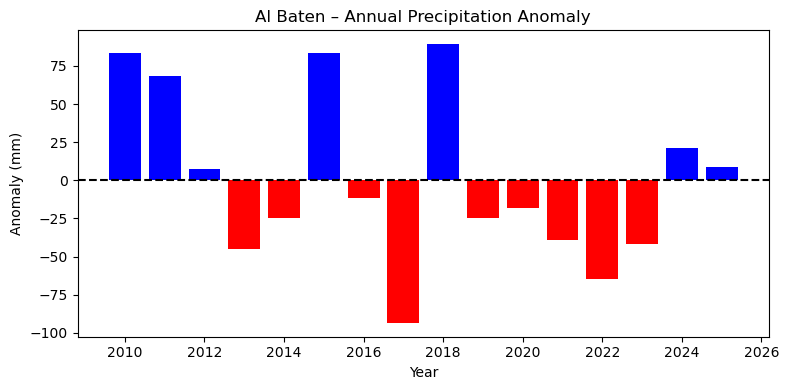

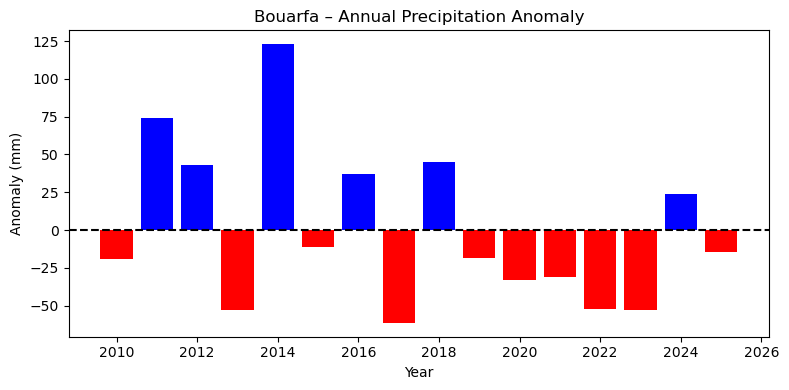

In [89]:
# based on merged monthly climate data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load data
# df
folder = "C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Climate data/GEE_Clim_exports"
df = pd.read_csv(os.path.join(folder, "ERA5_monthly_10-25_AI Baten_Bouarfa_merged.csv"))

# Ensure datetime
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
sites = df["area_id"].unique()

# I have to (1)build-up base line, see which year has more precipitation
# 1. Identify wet/dry years (baseline comparison)
annual_precip = (
    df.groupby(["year", "area_id"])["precip_mm"]
    .sum()
    .reset_index()
)

# refercing baseline
# Compute baseline per site
annual_precip["baseline"] = (
    annual_precip.groupby("area_id")["precip_mm"]
    .transform("mean")
)

# Compute anomaly
annual_precip["anomaly"] = (
    annual_precip["precip_mm"] - annual_precip["baseline"]
)

# Plot wet/dry years (bar chart)
for site in sites:
    subset = annual_precip[annual_precip["area_id"] == site]
    
    plt.figure(figsize=(8,4))
    
    colors = subset["anomaly"].apply(lambda x: "blue" if x > 0 else "red")
    
    plt.bar(subset["year"], subset["anomaly"], color=colors)
    plt.axhline(0, linestyle="--", color="black")
    
    plt.title(f"{site} – Annual Precipitation Anomaly")
    plt.xlabel("Year")
    plt.ylabel("Anomaly (mm)")
    
    plt.tight_layout()
    plt.show()


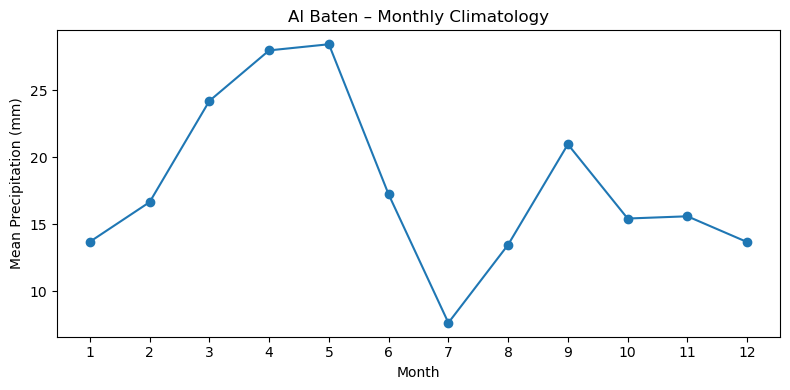

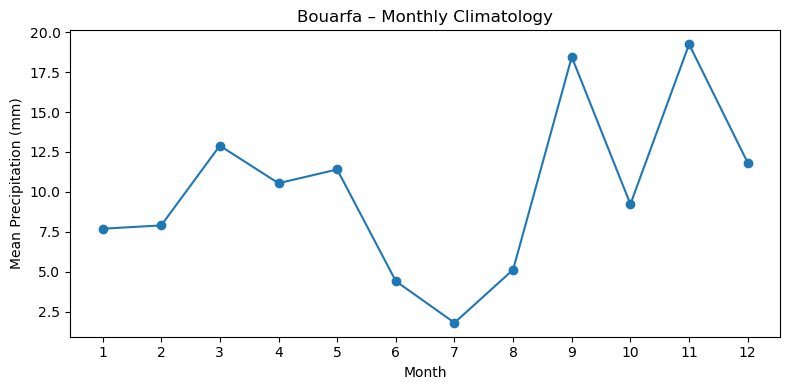

Wettest years per site:
     area_id  year   precip_mm
16  Al Baten  2018  303.996975
9    Bouarfa  2014  243.340362


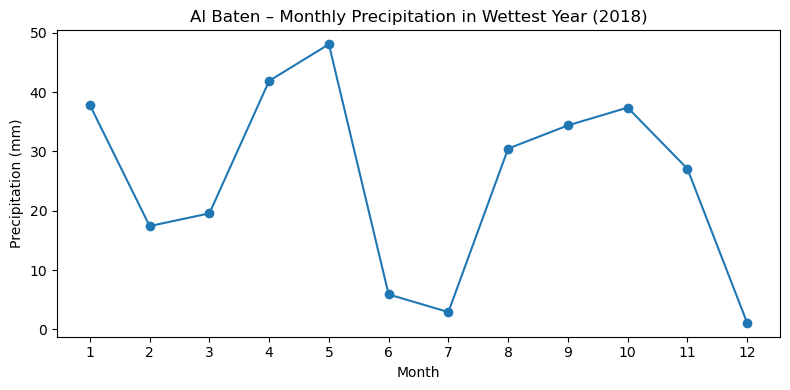

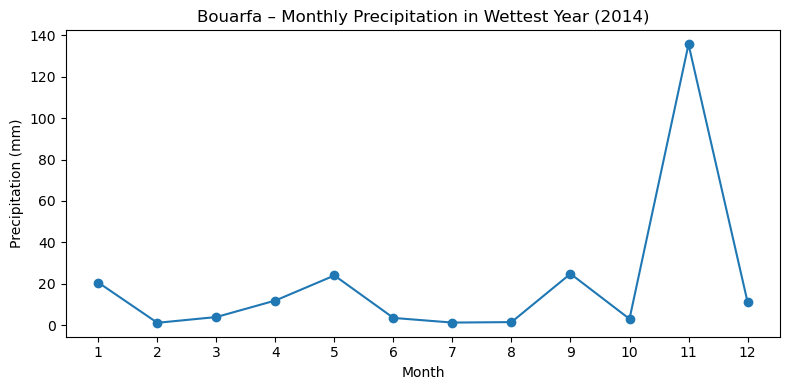


Top 3 wettest months (climatology) per site:
    month   area_id  precip_mm
8       5  Al Baten  28.426472
6       4  Al Baten  27.968572
4       3  Al Baten  24.196676
21     11   Bouarfa  19.247607
17      9   Bouarfa  18.453512
5       3   Bouarfa  12.891772


In [94]:
# Identify month(s):(2) see monthly trajetories, and identify the most rainfall month for conducting water body mask
# Approach A: Climatology (monthly average across years)
monthly_climatology = (
    df.groupby(["month", "area_id"])["precip_mm"]
    .mean()
    .reset_index()
)

# Plot climatology
for site in sites:
    subset = monthly_climatology[monthly_climatology["area_id"] == site]
    
    plt.figure(figsize=(8,4))
    plt.plot(subset["month"], subset["precip_mm"], marker='o')
    
    plt.xticks(range(1,13))
    plt.title(f"{site} – Monthly Climatology")
    plt.xlabel("Month")
    plt.ylabel("Mean Precipitation (mm)")
    
    plt.tight_layout()
    plt.show()
    
# Approach B: Focus on wettest year
# 2.1 Find wettest year
# Identify wettest year per site
wettest_years = (
    annual_precip.loc[
        annual_precip.groupby("area_id")["precip_mm"].idxmax()
    ][["area_id", "year", "precip_mm"]]
)

print("Wettest years per site:")
print(wettest_years)

# 2.2 Extract monthly precipitation for that year
for _, row in wettest_years.iterrows():
    site = row["area_id"]
    year = row["year"]
    
    subset = df[(df["area_id"] == site) & (df["year"] == year)]
    
    plt.figure(figsize=(8,4))
    plt.plot(subset["month"], subset["precip_mm"], marker='o')
    
    plt.xticks(range(1,13))
    plt.title(f"{site} – Monthly Precipitation in Wettest Year ({year})")
    plt.xlabel("Month")
    plt.ylabel("Precipitation (mm)")
    
    plt.tight_layout()
    plt.show()

# 2.3 Plot
top_months = (
    monthly_climatology.sort_values(["area_id", "precip_mm"], ascending=[True, False])
    .groupby("area_id")
    .head(3)
)

print("\nTop 3 wettest months (climatology) per site:")
print(top_months)

In [96]:
import matplotlib.pyplot as plt

def plot_monthly_precip(df, area_id, year=None, ax=None):
    """
    Plot monthly precipitation for a given site (area_id).
    
    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns: ['area_id', 'year', 'month', 'precip_mm']
    area_id : str or int
        Site identifier
    year : int or None
        If provided → plot specific year
        If None → plot climatology (mean across years)
    ax : matplotlib axis (optional)
        For subplot usage
    """
    
    # Filter site
    subset = df[df["area_id"] == area_id]
    
    if subset.empty:
        raise ValueError(f"No data found for area_id={area_id}")
    
    # If specific year → plot that year
    if year is not None:
        subset = subset[subset["year"] == year]
        
        if subset.empty:
            raise ValueError(f"No data for area_id={area_id}, year={year}")
        
        plot_df = subset.groupby("month")["precip_mm"].sum().reset_index()
        title = f"{area_id} – Monthly Precipitation ({year})"
    
    # If no year → climatology
    else:
        plot_df = (
            subset.groupby("month")["precip_mm"]
            .mean()
            .reset_index()
        )
        title = f"{area_id} – Monthly Climatology"
    
    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,4))
    
    ax.plot(plot_df["month"], plot_df["precip_mm"], marker='o')
    ax.set_xticks(range(1,13))
    ax.set_xlabel("Month")
    ax.set_ylabel("Precipitation (mm)")
    ax.set_title(title)
    
    return ax

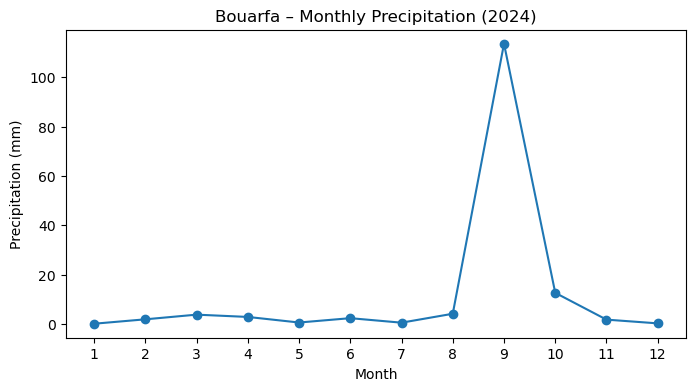

In [97]:
plot_monthly_precip(df, area_id="Bouarfa", year=2024)
plt.show()

# Vegetation dyanmics VS. Climate drivers (refer to 'GEE & Python Workflow-v2.ipynb.ipynb')

In [49]:
# Ranfom Forest predicted Vegetaion alive cover

# the RF predicted vegetation cover

import os

outdir = 'RF_Prediction'
os.makedirs(outdir, exist_ok=True)

# List of filenames
filenames = ['rf_pred_landsat_26.csv', 'rf_pred_sentinel2_26.csv', 'rf_pred_modis_26.csv', 'rf_pred_all_26.csv']

# Combine directory + filenames to get full paths
pred_csv_paths = [os.path.join(outdir, f) for f in filenames]

# read the predicteion DataFrame from corresponding path
# from 2017-2025
pre_landsat = pd.read_csv(pred_csv_paths[0])
pre_sentinel2 = pd.read_csv(pred_csv_paths[1])
pre_modis = pd.read_csv(pred_csv_paths[2])
pre_all = pd.read_csv(pred_csv_paths[3], low_memory=False)

print(pre_landsat.shape)
print(pre_sentinel2.shape)
print(pre_modis.shape)
print(pre_all.shape)


(48599, 18)
(54659, 18)
(46984, 19)
(150242, 19)


In [58]:
pre = pre_all.copy()

pre["date"] = pd.to_datetime(pre["date"], errors="coerce")

# ensure station_id naming consistent
pre = pre.rename(columns={"Station": "station_id"})
print(pre.shape)
print(pre.columns.tolist())

(150242, 19)
['Code', 'EVI', 'Habitat', 'Lat', 'Lon', 'MNDWI', 'MSAVI', 'NBR', 'NBR2', 'NDMI', 'NDVI', 'NDWI', 'SAVI', 'station_id', 'Work_area', 'date', 'F_alive_Pred', 'Sensor', 'Sub_area']


In [53]:
# Grouping the 114 trophic stations into independent ERA5 climate units
import geopandas as gpd
station_info = gpd.read_file("Trophic_stations_with_grid.shp")

station_df = station_info[["Station", "grid_id"]].copy()
station_df = station_df.rename(columns={"Station": "station_id"})


In [75]:
# Grabing the climate CSV file
import pandas as pd
import glob
import os

# Folder containing exported CSVs
# from 2010-2025
folder = "C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Climate data/GEE_Clim_exports"
climate = pd.read_csv(os.path.join(folder, "ERA5_daily_10-25_stations_merged.csv"))
climate["date"] = pd.to_datetime(climate["date"])

In [59]:
# Attach grid_id to vegetation
pre = pre.merge(station_df, on="station_id", how="left")
# Aggregate vegetation to grid level
# (important to remove pseudo-replication)
veg_grid = (
    pre.groupby(["grid_id", "date"])
    .agg({"F_alive_Pred": "mean"})
    .reset_index()
)

# # additional reamin the 'Habitat'
# habitat = station_info[["Station", "Habitat_2_"]]

# pre = pre.merge(habitat, on="station_id", how="left")

# veg_grid = (
#     pre.groupby(["grid_id", "date"])
#     .agg({
#         "F_alive_Pred": "mean",
#         "Habitat_2_": lambda x: x.mode()[0] if len(x.mode()) > 0 else None
#     })
#     .reset_index()
# )

# Aggregate vegetation to weekly
veg_grid["week"] = veg_grid["date"].dt.to_period("W")

veg_weekly = (
    veg_grid.groupby(["grid_id", "week"])
    .agg({"F_alive_Pred": "mean"})
    .reset_index()
)

In [69]:
print(climate.columns.tolist())

['station_id', 'habitat', 'date', 'precip_mm', 'temp2m_C', 'temp2m_C_max', 'temp2m_C_min']


In [76]:
# Attach grid_id and aggerate daily to weekly for climate
# --- prepare time ---
# climate["date"] = pd.to_datetime(climate["date"])
# climate["week"] = climate["date"].dt.to_period("W")

# clim_weekly = (
#     climate.groupby(["grid_id", "week"])
#     .agg({
#         "precip_mm": ["sum", "max"],
#         "temp2m_C": "mean",
#         "temp2m_C_max": "max",
#         "temp2m_C_min": "min"
#     })
# )

# # --- clean columns ---
# clim_weekly.columns = ["_".join(col) for col in clim_weekly.columns]
# clim_weekly = clim_weekly.reset_index()

# Use ISO week (Monday to Sunday) to aggerate weekly
climate['date'] = pd.to_datetime(climate['date'])
climate['week'] = climate['date'].dt.isocalendar().week
climate['year'] = climate['date'].dt.isocalendar().year

# --- attach grid ---
climate = climate.merge(station_df, on="station_id", how="left")

# --- aggregate ---
clim_weekly = (
    climate.groupby(['grid_id', 'year', 'week'])
    .agg({
        'precip_mm': 'sum',
        'temp2m_C': 'mean',
        'temp2m_C_max': 'max',
        'temp2m_C_min': 'min',
        'station_id': lambda x: list(x.unique())  # keep station IDs as list
    })
    .reset_index()
)

clim_weekly.head()

,grid_id,year,week,precip_mm,temp2m_C,temp2m_C_max,temp2m_C_min,station_id
0,29.1_-8.5,2009,53,0.008523,14.922836,21.589273,3.816339,"[NN42SE1, NN42SE2, NN42SE3, NN42SE4, NN42SE5]"
1,29.1_-8.5,2010,1,3.113398,13.809245,24.184671,1.374185,"[NN42SE1, NN42SE2, NN42SE3, NN42SE4, NN42SE5]"
2,29.1_-8.5,2010,2,0.037233,18.088368,29.026636,7.423257,"[NN42SE1, NN42SE2, NN42SE3, NN42SE4, NN42SE5]"
3,29.1_-8.5,2010,3,0.023472,17.531333,26.899057,6.291864,"[NN42SE1, NN42SE2, NN42SE3, NN42SE4, NN42SE5]"
4,29.1_-8.5,2010,4,3.041840,13.078578,25.702646,1.293283,"[NN42SE1, NN42SE2, NN42SE3, NN42SE4, NN42SE5]"


In [78]:
clim_weekly.to_csv(os.path.join(folder, "ERA5_weekly_10-25_stations_grided.csv"), index=False)

In [79]:
import pandas as pd

# Convert dates and extract ISO week and year
climate['date'] = pd.to_datetime(climate['date'])
climate['week'] = climate['date'].dt.isocalendar().week
climate['year'] = climate['date'].dt.isocalendar().year

# Weekly aggregation per station
station_weekly = (
    climate.groupby(['station_id', 'year', 'week'])
    .agg({
        'precip_mm': 'sum',         # sum daily precipitation
        'temp2m_C': 'mean',         # average daily mean temp
        'temp2m_C_max': 'max',      # max daily max temp
        'temp2m_C_min': 'min'       # min daily min temp
    })
    .reset_index()
    
)

# only the average by stations
station_weekly.to_csv(os.path.join(folder, "ERA5_weekly_10-25_stations.csv"), index=False)

In [65]:
# Merge climate + vegetation
data = veg_weekly.merge(
    clim_weekly,
    on=["grid_id", "week"],
    how="inner"
)

# Add lag features (critical)
data = data.sort_values(["grid_id", "week"])

lags = [1, 2, 4]

for lag in lags:
    data[f"precip_lag{lag}"] = (
        data.groupby("grid_id")["precip_mm_sum"].shift(lag)
    )
    data[f"temp_lag{lag}"] = (
        data.groupby("grid_id")["temp2m_C_mean"].shift(lag)
    )

# Add cumulative precipitation
data["precip_2w"] = (
    data.groupby("grid_id")["precip_mm_sum"]
    .rolling(2).sum().reset_index(0, drop=True)
)

data = data.dropna()
print(data.shape)


(9336, 15)


In [ ]:
# Coupling analysis
- some suggusted methods
1. 